<div style="background: linear-gradient(135deg, #0072B2 0%, #004f7a 100%); color: #ffffff; padding: 32px 38px; border-radius: 12px; margin: 0 0 22px 0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif;"><div style="font-size: 11px; letter-spacing: 2.5px; text-transform: uppercase; opacity: 0.75; margin-bottom: 6px; font-weight: 500;">Analyse de Données avec Python pour Professionnels de la Santé</div><h1 style="margin: 0; font-size: 30px; font-weight: 600; color: #ffffff; line-height: 1.2; border: none; padding: 0;"><span style="opacity: 0.65; font-weight: 400;">Module 3</span><span style="opacity: 0.4; margin: 0 12px;">·</span>Visualisation</h1><div style="margin-top: 14px; font-size: 14px; opacity: 0.9;">Version condensee 6 heures  ·  Module 3 sur 6  ·  Duree 60 minutes</div></div><div style="margin: 0 0 22px 0;"><span style="display: inline-block; background: #e8f4f8; color: #005c8f; padding: 5px 14px; border-radius: 14px; font-size: 12px; margin: 0 6px 6px 0; font-weight: 500; border: 1px solid #b8dde9; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;">Niveau intermediaire</span><span style="display: inline-block; background: #fff4eb; color: #a64a00; padding: 5px 14px; border-radius: 14px; font-size: 12px; margin: 0 6px 6px 0; font-weight: 500; border: 1px solid #f0c89d; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;">Duree 60 min</span><span style="display: inline-block; background: #f5f0fa; color: #5a3380; padding: 5px 14px; border-radius: 14px; font-size: 12px; margin: 0 6px 6px 0; font-weight: 500; border: 1px solid #d4c0e8; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;">Prerequis : Module 1</span><span style="display: inline-block; background: #f3f3f3; color: #555555; padding: 5px 14px; border-radius: 14px; font-size: 12px; margin: 0 6px 6px 0; font-weight: 500; border: 1px solid #d0d0d0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;">Colab compatible</span></div><div style="margin: 0 0 18px 0;"><a href="https://colab.research.google.com/github/gabayae/-python-sante/blob/main/notebooks_vierges/module_03_visualisation.ipynb" target="_blank" style="text-decoration: none;"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab" style="vertical-align: middle;"/></a></div><div style="border: 1px solid #e0e0e0; border-left: 4px solid #009E73; background: #fafbfc; padding: 18px 22px; margin: 20px 0; border-radius: 0 6px 6px 0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;"><div style="font-size: 11px; letter-spacing: 1.5px; color: #009E73; font-weight: 600; margin-bottom: 10px;">OBJECTIFS DU MODULE</div><ul style="margin: 0; padding-left: 22px; color: #333; font-size: 14px;"><li style="margin: 6px 0; line-height: 1.5;">Choisir le bon <strong>type de graphique</strong> pour une question donnée.</li><li style="margin: 6px 0; line-height: 1.5;">Produire les graphiques de base avec matplotlib et seaborn : <strong>histogramme, boîte a moustaches, barres, ligne, nuage de points, heatmap</strong>.</li><li style="margin: 6px 0; line-height: 1.5;">Annoter chaque figure avec <strong>axes etiquetes, unites, taille d'échantillon, seuils cliniques</strong>.</li><li style="margin: 6px 0; line-height: 1.5;">Choisir une <strong>palette accessible aux daltoniens</strong> par défaut.</li><li style="margin: 6px 0; line-height: 1.5;">Composer un <strong>tableau de bord</strong> multi-panneaux.</li></ul></div><div style="border-left: 4px solid #0072B2; background: #f0f7fb; padding: 14px 18px; margin: 18px 0; border-radius: 0 6px 6px 0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;"><div style="font-weight: 600; color: #005c8f; font-size: 11px; letter-spacing: 1.2px; margin-bottom: 6px;">REGLES POUR TOUTE FIGURE EN SANTÉ</div><div style="color: #333; font-size: 14px; line-height: 1.5;">Axes etiquetes avec leur <strong>unite</strong> (<code>Tension (mmHg)</code>, jamais juste <code>BP</code>). Les barres commencent a zero. <strong>Pas</strong> de 3D, <strong>pas</strong> de camemberts au-dela de 3 parts, <strong>pas</strong> de double axe Y. Palette <strong>accessible</strong> (Wong 2011 ; Okabe-Ito 2008). Annoter <strong>taille d'échantillon</strong> (<code>n = 1234</code>) et <strong>seuils cliniques</strong>.</div></div>

## 0. Setup matplotlib + seaborn

> **Syntaxe — figure + axes en matplotlib**
> ```python
> fig, ax = plt.subplots(figsize=(largeur, hauteur))   # 1 figure 1 axes
> fig, axes = plt.subplots(nrows, ncols, figsize=(...))   # grille
> ax.plot(x, y)                # méthode du AxesSubplot
> ax.set_xlabel("...")
> ax.set_ylabel("...")
> ax.set_title("...")
> plt.tight_layout()          # rearrange les marges
> plt.show()                  # affiche
> ```
> On préfère l'API **orientee objet** (`fig, ax = ...`) a l'API fonctionnelle (`plt.plot(...)`) : plus claire des qu'on a plusieurs sous-graphes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt           # convention : plt
import seaborn as sns                     # convention : sns
from scipy import stats                   # pour les correlations etc.

np.random.seed(42)

# set_theme() applique un style coherent a TOUS les graphes seaborn et matplotlib
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.figsize"] = (8, 5)   # taille par défaut
plt.rcParams["figure.dpi"] = 100          # densite de pixels

# Palette de 8 couleurs accessible aux daltoniens (Wong, Nature Methods 2011).
# Les codes commencant par # sont des couleurs hexadecimales (RGB).
CB = ["#0072B2", "#D55E00", "#009E73",
      "#CC79A7", "#F0E442", "#56B4E9",
      "#E69F00", "#999999"]
sns.set_palette(CB)

In [2]:
import os
from pathlib import Path
import pandas as pd

# Chemins de cache candidats, dans l'ordre :
#   1. ./data/         (jupyter local, notebook a la racine)
#   2. ../data/        (jupyter local, notebook dans un sous-dossier)
#   3. ./             (au pire on cree un cache dans le cwd)
# En Colab, aucun n'existe : on tombe sur l'URL et on cree ./data/ pour les
# cellules suivantes.
_CANDIDATES = [Path("data"), Path("../data")]
DATA_DIR = next((p for p in _CANDIDATES if p.is_dir()), Path("data"))
DATA_DIR.mkdir(exist_ok=True)


def load_csv(name: str, url: str, **read_csv_kwargs) -> pd.DataFrame:
    """Charge un CSV : cache local d'abord, sinon URL publique.

    Le cache utilise le meme separateur que la lecture (TSV reste TSV).
    """
    for candidate_dir in _CANDIDATES:
        local = candidate_dir / name
        if local.exists():
            return pd.read_csv(local, **read_csv_kwargs)
    df = pd.read_csv(url, **read_csv_kwargs)
    try:
        sep = read_csv_kwargs.get("sep", ",")
        (DATA_DIR / name).parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(DATA_DIR / name, index=False, sep=sep)
    except OSError:
        pass
    return df

GAPMINDER_URL = (
    "https://raw.githubusercontent.com/jennybc/gapminder/"
    "master/inst/extdata/gapminder.tsv"
)
gm = load_csv("gapminder.tsv", GAPMINDER_URL, sep="\t")
recent = gm[gm["year"] == 2007]
print(f"Gapminder : {len(gm):,} lignes ; focus 2007 ({len(recent)} pays)")

Gapminder : 1,704 lignes ; focus 2007 (142 pays)


## 1. Distributions — histogramme et KDE

Un **histogramme** montre comment une variable continue est répartie.

Le nombre de classes (`bins`) compte : trop peu cache la structure, trop transforme le graphe en bruit. Defaut habituel : $k \approx \sqrt{n}$.

Une **estimation de densite** (KDE) est une version lissee de l'histogramme. Utile pour comparer plusieurs distributions sur les mêmes axes.

> **Syntaxe — histogramme matplotlib**
> ```python
> ax.hist(données, bins=20, color="...", edgecolor="white")
> ax.axvline(x, color="red", ls="--", label="...")  # ligne verticale
> ax.legend()              # affiche la legende
> ```

> **Syntaxe — KDE seaborn**
> ```python
> sns.kdeplot(data=df, x="col", hue="col_categ", fill=True, ax=ax)
> ```

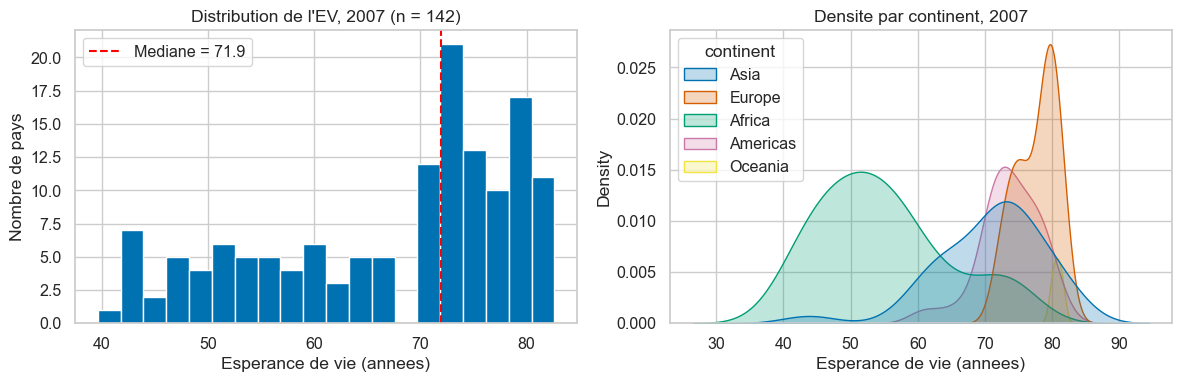

In [3]:
# Une figure avec 2 panneaux côte a côte : 1 ligne, 2 colonnes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ---- Panneau gauche : histogramme + mediane ----
axes[0].hist(
    recent["lifeExp"],
    bins=20,                 # 20 classes
    edgecolor="white",      # bord blanc entre les barres
    color=CB[0],             # 1ere couleur de la palette
)
# Ligne verticale au niveau de la mediane
axes[0].axvline(
    recent["lifeExp"].median(),
    color="red", ls="--",
    label=f"Mediane = {recent['lifeExp'].median():.1f}",
)
axes[0].set_xlabel("Esperance de vie (annees)")     # toujours indiquer l'unite
axes[0].set_ylabel("Nombre de pays")
axes[0].set_title(f"Distribution de l'EV, 2007 (n = {len(recent)})")
axes[0].legend()

# ---- Panneau droit : densites par continent ----
sns.kdeplot(data=recent, x="lifeExp", hue="continent",
            fill=True, alpha=0.25, ax=axes[1])    # alpha = transparence
axes[1].set_xlabel("Esperance de vie (annees)")
axes[1].set_title("Densite par continent, 2007")

plt.tight_layout()        # ajuste les marges automatiquement
plt.show()                # affiche la figure

### Exemple clinique — distribution de la glycémie

Quand la population est un melange (normaux, pre-diabetiques, diabetiques), l'histogramme suffit a raconter l'histoire et les seuils cliniques (100 et 126 mg/dL) rendent la figure actionnable.

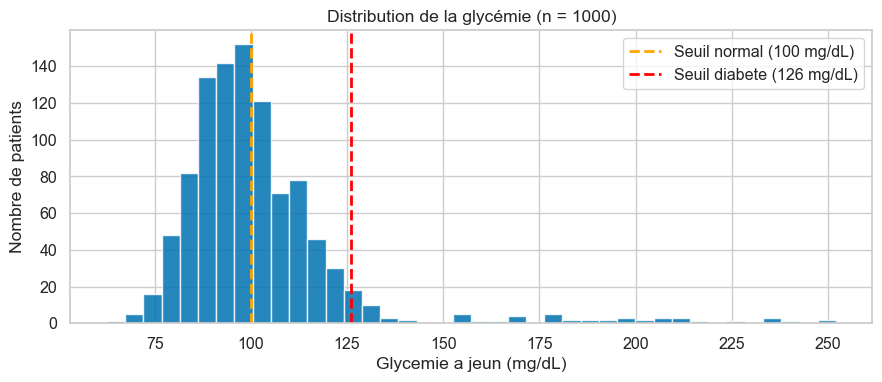

In [4]:
# Simulation d'une population mixte (1000 sujets total)
# np.random.normal(moyenne, écart-type, n) tire n nombres dans N(mu, sigma)
normaux  = np.random.normal(95, 10, 800)     # 800 patients normaux
prediab  = np.random.normal(115, 8, 150)     # 150 pre-diabétiques
diabet   = np.random.normal(180, 40, 50)     # 50 diabétiques

# np.concatenate fusionne plusieurs tableaux en un seul
all_g = np.concatenate([normaux, prediab, diabet])

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(all_g, bins=40, edgecolor="white", color=CB[0], alpha=0.85)
ax.axvline(100, color="orange", ls="--", lw=2,
           label="Seuil normal (100 mg/dL)")     # cut-off pre-diabète
ax.axvline(126, color="red",    ls="--", lw=2,
           label="Seuil diabete (126 mg/dL)")    # cut-off diabète
ax.set_xlabel("Glycemie a jeun (mg/dL)")
ax.set_ylabel("Nombre de patients")
ax.set_title(f"Distribution de la glycémie (n = {len(all_g)})")
ax.legend()
plt.tight_layout(); plt.show()

## 2. Comparer entre groupes — boîtes a moustaches (boxplot)

Anatomie :

- la boîte va de **Q1 a Q3** (l'IQR) ;
- la barre interieure est la **mediane** ;
- les moustaches s'etendent au dernier point dans **1,5 x IQR** ;
- les points au-dela sont des valeurs aberrantes individuelles.

Les boîtes **cachent la bimodalite**. En cas de doute, superposer un stripplot ou ajouter un histogramme/KDE en parallele.

> **Syntaxe — boxplot seaborn**
> ```python
> sns.boxplot(data=df, x="col_categ", y="col_num", ax=ax)
> sns.boxplot(data=df, x="c1", y="y", hue="c2", ax=ax)   # avec couleur par c2
> ```

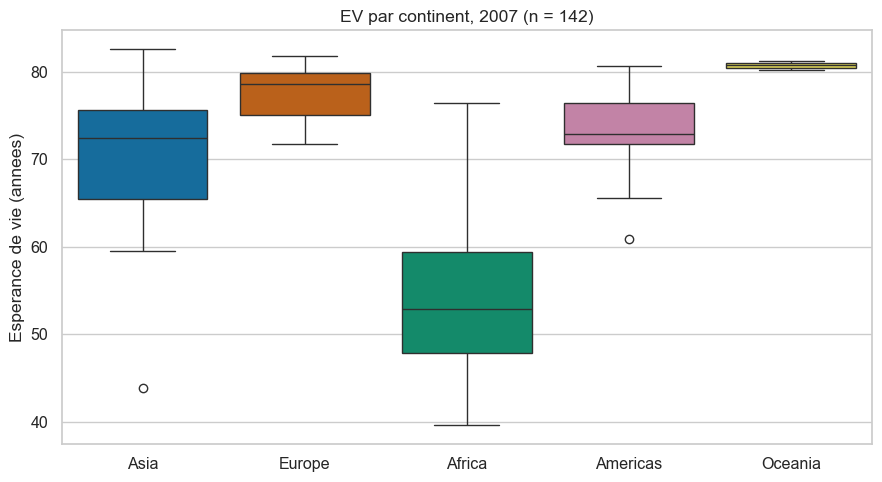

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

# n_cont sert juste a truncate la palette au nombre de groupes
# (évite un avertissement seaborn)
n_cont = recent["continent"].nunique()

sns.boxplot(
    data=recent, x="continent", y="lifeExp", ax=ax,
    hue="continent", legend=False,      # couleur par continent (sans legende redondante)
    palette=CB[:n_cont],                # premières n_cont couleurs
)
ax.set_xlabel("")                       # ici inutile - les noms sont sous les boîtes
ax.set_ylabel("Esperance de vie (annees)")
ax.set_title(f"EV par continent, 2007 (n = {len(recent)})")
plt.tight_layout(); plt.show()

## 3. Barres — comparer des comptes ou des taux

Les barres **doivent** commencer a zero (sinon : graphique trompeur).

Pour des **classements** (top-15, bottom-10), des **barres horizontales** avec la valeur la plus élevée en haut sont plus lisibles : les noms de pays se lisent dans le sens normal de lecture.

> **Syntaxe — barres horizontales**
> ```python
> ax.barh(noms, valeurs, color="...")
> ax.invert_yaxis()       # met la 1ere valeur en haut
> ax.text(x, y, "label")  # texte place a (x, y) en coordonnees données
> ```

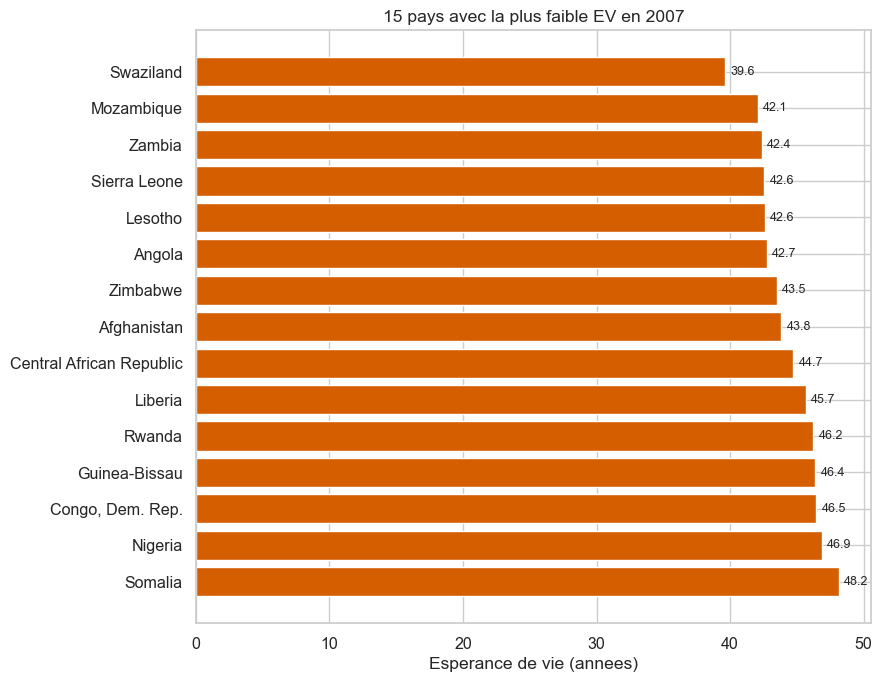

In [6]:
# Les 15 pays avec la PLUS FAIBLE espérance de vie
bottom15 = recent.nsmallest(15, "lifeExp")

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(bottom15["country"], bottom15["lifeExp"], color=CB[1])
ax.set_xlabel("Esperance de vie (annees)")
ax.set_title("15 pays avec la plus faible EV en 2007")
ax.invert_yaxis()            # 1ere ligne du nsmallest -> tout en haut

# Boucle pour annoter chaque barre avec sa valeur
# enumerate() donne (indice, valeur)
for i, v in enumerate(bottom15["lifeExp"]):
    ax.text(v + 0.4, i, f"{v:.1f}", va="center", fontsize=9)

plt.tight_layout(); plt.show()

## 4. Tendance temporelle — lignes et courbes épidémiques

Lignes pour des series temporelles continues. Toujours preciser ce que la ligne represente : effectif brut, moyenne lissee, taux pour 100 000.

> **Syntaxe — ligne avec marqueurs**
> ```python
> ax.plot(x, y, marker="o", markersize=4, label="...")
> ```

> **Syntaxe — boucle sur les groupes uniques**
> ```python
> for cat in df["col_categ"].unique():
>     sub = df[df["col_categ"] == cat]
>     ax.plot(sub["x"], sub["y"], label=cat)
> ```

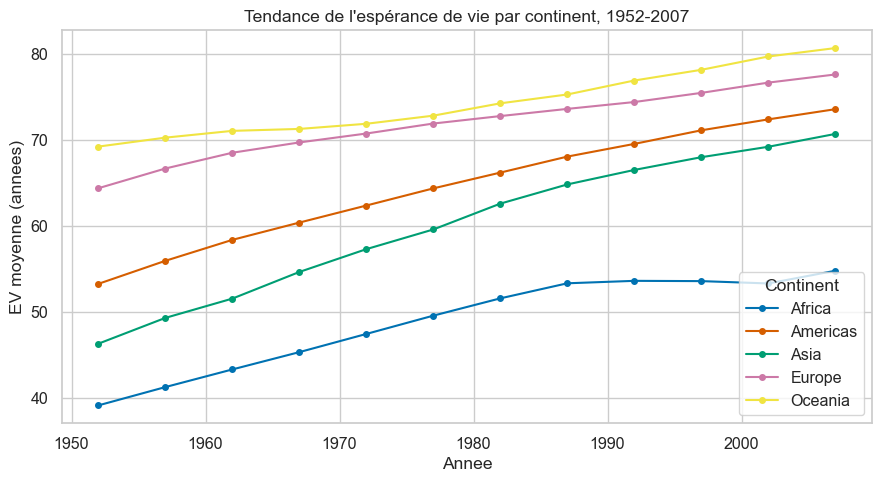

In [7]:
# Moyenne d'EV par année et par continent -> tableau long format
# .reset_index() transforme le MultiIndex en colonnes normales
tendance = gm.groupby(["year", "continent"])["lifeExp"].mean().reset_index()

fig, ax = plt.subplots(figsize=(9, 5))

# Trace une ligne par continent
# i % len(CB) : modulo - cycle les couleurs si plus de continents que de couleurs
for i, cont in enumerate(sorted(tendance["continent"].unique())):
    sub = tendance[tendance["continent"] == cont]
    ax.plot(sub["year"], sub["lifeExp"], marker="o", markersize=4,
            color=CB[i % len(CB)], label=cont)

ax.set_xlabel("Annee")
ax.set_ylabel("EV moyenne (annees)")
ax.set_title("Tendance de l'espérance de vie par continent, 1952-2007")
ax.legend(title="Continent")
plt.tight_layout(); plt.show()

### Courbe épidémique

Patron standard : **barres journalieres + moyenne mobile 7 jours** en haut, **courbe cumulee** en bas.

> **Syntaxe — series de dates**
> ```python
> dates = pd.date_range("2023-01-01", periods=120, freq="D")  # 120 jours consecutifs
> s.rolling(window=7).mean()                                  # moyenne mobile 7 jours
> s.cumsum()                                                  # somme cumulee
> ```

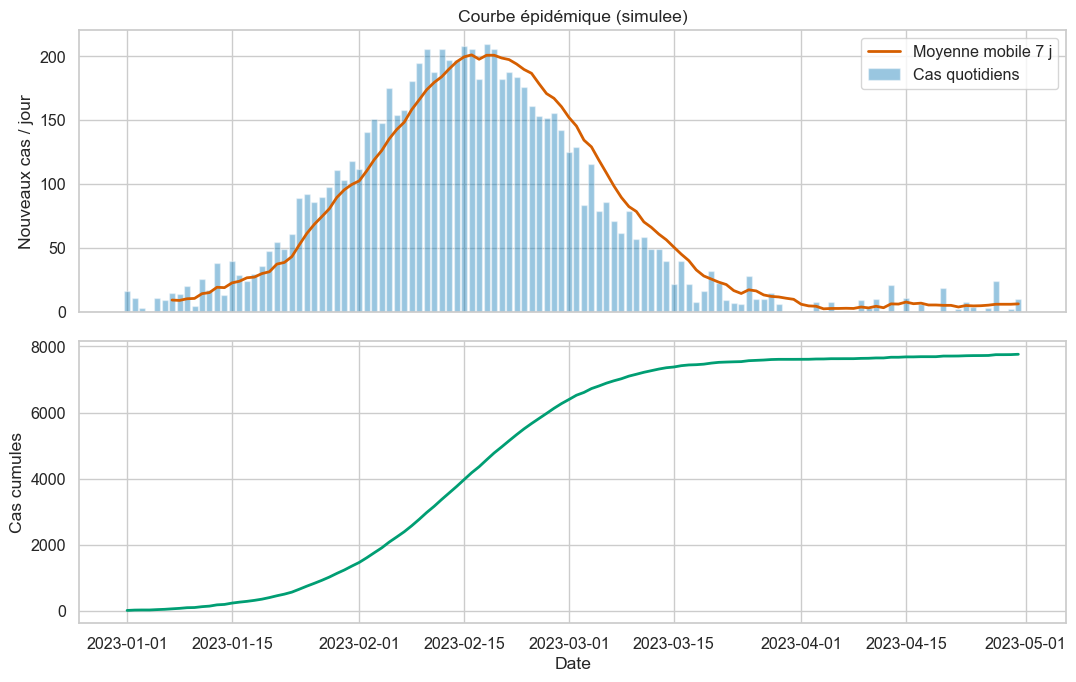

In [8]:
# 120 jours a partir du 1er janvier 2023, fréquence quotidienne
jours = pd.date_range("2023-01-01", periods=120, freq="D")
t = np.arange(120)                                # 0, 1, 2, ..., 119

# Forme gaussienne autour du jour 45 + bruit aléatoire
# np.maximum(0, x) prend max(0, x) element par element
cas = np.maximum(0, 200 * np.exp(-0.5 * ((t - 45) / 15) ** 2)
                   + np.random.normal(0, 10, 120)).astype(int)

epi = pd.DataFrame({"date": jours, "nouveaux_cas": cas})
epi["mm_7j"]  = epi["nouveaux_cas"].rolling(7).mean()    # moyenne mobile 7 j
epi["cumule"] = epi["nouveaux_cas"].cumsum()              # cumul depuis le debut

# 2 lignes 1 colonne, sharex=True : même axe X partage
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

# Panneau haut : barres + moyenne mobile
axes[0].bar(epi["date"], epi["nouveaux_cas"], alpha=0.4, color=CB[0],
            label="Cas quotidiens")
axes[0].plot(epi["date"], epi["mm_7j"], color=CB[1], lw=2,
             label="Moyenne mobile 7 j")
axes[0].set_ylabel("Nouveaux cas / jour")
axes[0].set_title("Courbe épidémique (simulee)")
axes[0].legend()

# Panneau bas : cumul
axes[1].plot(epi["date"], epi["cumule"], color=CB[2], lw=2)
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Cas cumules")

plt.tight_layout(); plt.show()

## 5. Associations — nuage de points (scatter plot)

Deux variables continues sur un même plan. L'exemple Gapminder utilise la **taille** des bulles pour encoder une 3e variable (population) et la **couleur** pour la 4e (continent).

> **Syntaxe — scatter**
> ```python
> ax.scatter(x, y, s=taille, alpha=0.6, color="...", label="...")
> ax.set_xscale("log")     # échelle log sur X (utile pour le PIB)
> ```

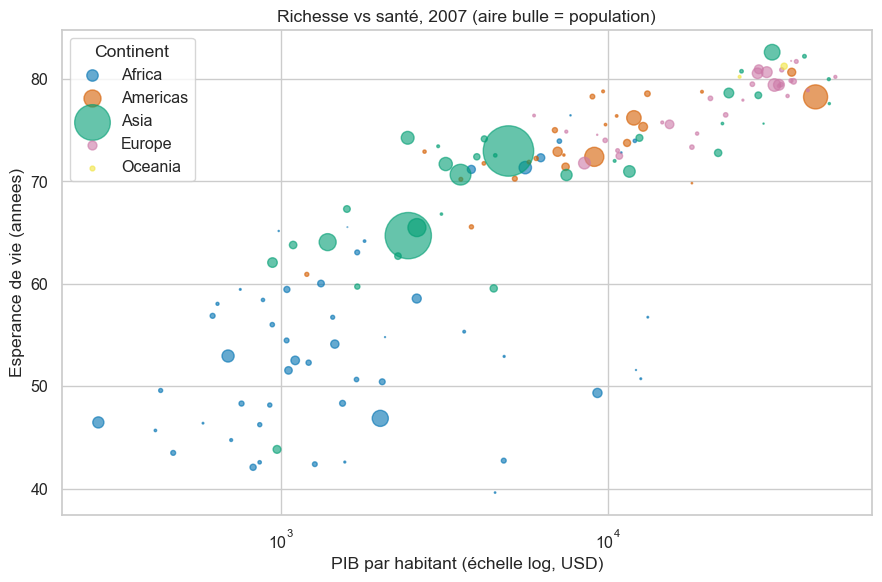

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))

# Boucle sur chaque continent pour pouvoir mettre une couleur + legende
for i, cont in enumerate(sorted(recent["continent"].unique())):
    sub = recent[recent["continent"] == cont]
    ax.scatter(
        sub["gdpPercap"],                # X = PIB par habitant
        sub["lifeExp"],                  # Y = espérance de vie
        s=sub["pop"] / 1e6,              # taille des bulles ~ population
        alpha=0.6,                       # transparence pour voir les chevauchements
        color=CB[i % len(CB)],
        label=cont,
    )

# Echelle log sur X : le PIB s'etale sur 4 ordres de grandeur
ax.set_xscale("log")
ax.set_xlabel("PIB par habitant (échelle log, USD)")
ax.set_ylabel("Esperance de vie (annees)")
ax.set_title("Richesse vs santé, 2007 (aire bulle = population)")
ax.legend(title="Continent")
plt.tight_layout(); plt.show()

## 6. Heatmap — matrice de correlations

On masque le triangle supérieur (redondant avec l'inférieur).

> **Syntaxe — heatmap seaborn**
> ```python
> corr = df.corr()                              # matrice de correlation
> sns.heatmap(corr, annot=True, fmt=".2f",       # 2 décimales
>             cmap="RdBu_r", center=0,            # rouge-bleu, centre sur 0
>             vmin=-1, vmax=1, square=True, ax=ax)
> ```

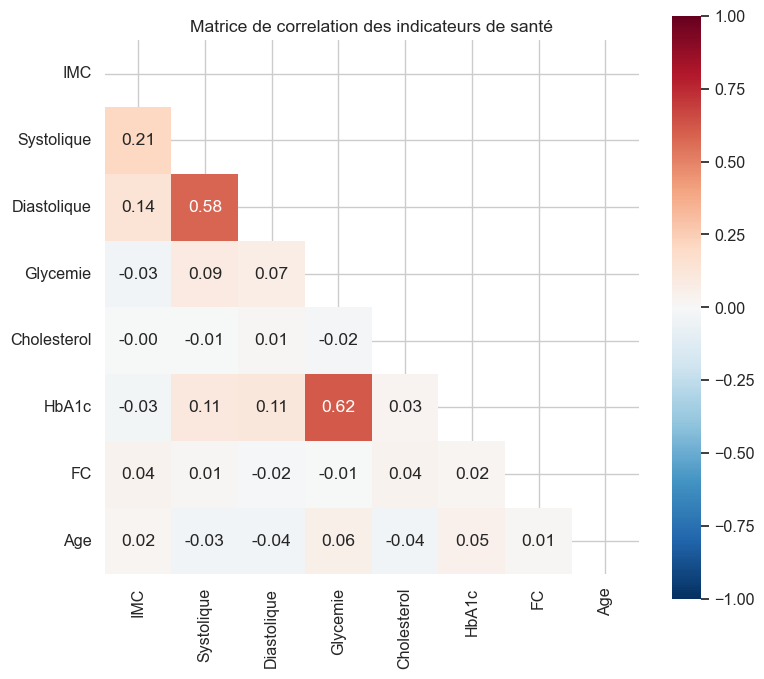

In [10]:
# Simulation de 300 patients avec 8 indicateurs
n = 300
santé = pd.DataFrame({
    "IMC":         np.random.normal(27, 5, n),
    "Systolique":  np.random.normal(130, 18, n),
    "Diastolique": np.random.normal(82, 10, n),
    "Glycemie":    np.random.normal(105, 25, n),
    "Cholesterol": np.random.normal(200, 40, n),
    "HbA1c":       np.random.normal(5.8, 1.2, n),
    "FC":          np.random.normal(72, 12, n),
    "Age":         np.random.normal(55, 15, n).clip(18, 90),
})

# Injection de correlations réalistes (en santé les variables sont rarement indépendantes)
santé["Systolique"]  += 0.8 * santé["IMC"]
santé["Glycemie"]    += 15  * santé["HbA1c"]
santé["Diastolique"] += 0.4 * santé["Systolique"]

# .corr() : matrice 8x8 de correlations de Pearson
corr = santé.corr()

# Masque pour cacher le triangle SUPERIEUR (info dupliquee)
# np.triu = 'upper triangle' (1 au-dessus de la diagonale, 0 sinon)
masque = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    corr,
    mask=masque,                  # masque le triangle supérieur
    annot=True, fmt=".2f",         # écrit les coefficients dans les cases
    cmap="RdBu_r", center=0,       # rouge=positif, bleu=negatif, blanc=0
    vmin=-1, vmax=1,              # échelle fixee
    square=True, ax=ax,
)
ax.set_title("Matrice de correlation des indicateurs de santé")
plt.tight_layout(); plt.show()

## 7. Tableau de bord 4 panneaux

Une seule figure qui repond a **une** question (état de la santé mondiale en 2007) avec quatre panneaux complementaires. On la sauvegarde pour la slide deck.

> **Syntaxe — grille de subplots + sauvegarde**
> ```python
> fig, axes = plt.subplots(2, 2, figsize=(13, 9))   # grille 2x2
> axes[0, 0]   # panneau haut-gauche
> axes[0, 1]   # panneau haut-droite
> # ...
> fig.suptitle("Titre global", fontsize=15, y=1.01)
> fig.savefig("figure.png", dpi=150, bbox_inches="tight")
> ```

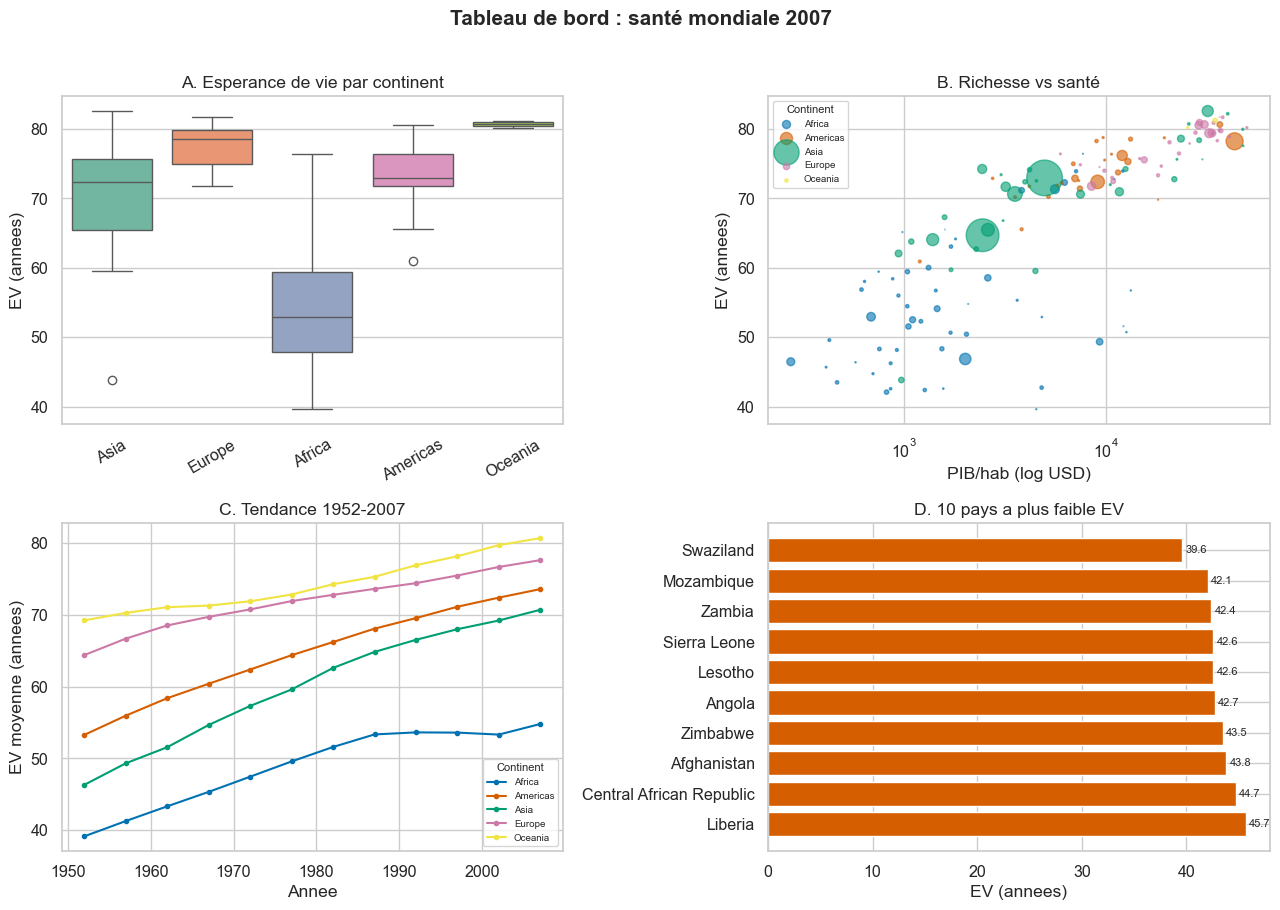

Sauvegarde -> tableau_de_bord_2007.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Tableau de bord : santé mondiale 2007",
             fontsize=15, fontweight="bold", y=1.01)

# ---- Panneau A : EV par continent ----
ax = axes[0, 0]
sns.boxplot(data=recent, x="continent", y="lifeExp",
            ax=ax, hue="continent", legend=False, palette="Set2")
ax.set_xlabel(""); ax.set_ylabel("EV (annees)")
ax.set_title("A. Esperance de vie par continent")
ax.tick_params(axis="x", rotation=30)

# ---- Panneau B : richesse vs santé ----
ax = axes[0, 1]
for i, cont in enumerate(sorted(recent["continent"].unique())):
    sub = recent[recent["continent"] == cont]
    ax.scatter(sub["gdpPercap"], sub["lifeExp"],
               s=sub["pop"] / 2e6, alpha=0.6,
               color=CB[i % len(CB)], label=cont)
ax.set_xscale("log")
ax.set_xlabel("PIB/hab (log USD)"); ax.set_ylabel("EV (annees)")
ax.set_title("B. Richesse vs santé")
ax.legend(fontsize=7, title="Continent", title_fontsize=8)

# ---- Panneau C : tendance ----
ax = axes[1, 0]
for i, cont in enumerate(sorted(tendance["continent"].unique())):
    sub = tendance[tendance["continent"] == cont]
    ax.plot(sub["year"], sub["lifeExp"], marker="o", markersize=3,
            color=CB[i % len(CB)], label=cont)
ax.set_xlabel("Annee"); ax.set_ylabel("EV moyenne (annees)")
ax.set_title("C. Tendance 1952-2007")
ax.legend(fontsize=7, title="Continent", title_fontsize=8)

# ---- Panneau D : 10 pays a plus faible EV ----
ax = axes[1, 1]
bottom10 = recent.nsmallest(10, "lifeExp")
ax.barh(bottom10["country"], bottom10["lifeExp"], color=CB[1])
ax.set_xlabel("EV (annees)"); ax.set_title("D. 10 pays a plus faible EV")
ax.invert_yaxis()
for i, v in enumerate(bottom10["lifeExp"]):
    ax.text(v + 0.3, i, f"{v:.1f}", va="center", fontsize=8)

plt.tight_layout()

# Sauvegarde haute qualité (150 dpi suffit pour slides ; 300 pour impression)
fig.savefig("tableau_de_bord_2007.png", dpi=150, bbox_inches="tight")
plt.show()
print("Sauvegarde -> tableau_de_bord_2007.png")

## 8. Exercices (avec corriges)


### Exercice 1 — Histogramme de la glycémie chez 500 patients simules
Avec les seuils 100 et 126 mg/dL annotes.

In [12]:
# Votre essai ici


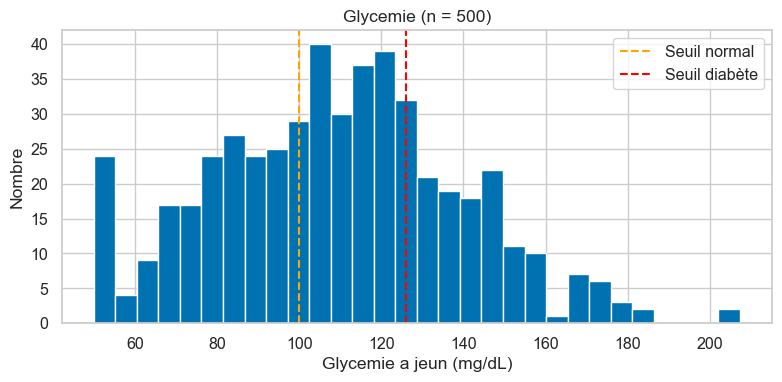

In [13]:
# Solution
# np.random.normal(mu, sigma, n).clip(lo, hi) tronque les valeurs extremes
g = np.random.normal(110, 30, 500).clip(50, 350)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(g, bins=30, color=CB[0], edgecolor="white")
ax.axvline(100, color="orange", ls="--", label="Seuil normal")
ax.axvline(126, color="red",    ls="--", label="Seuil diabète")
ax.set_xlabel("Glycemie a jeun (mg/dL)")
ax.set_ylabel("Nombre")
ax.set_title(f"Glycemie (n = 500)")
ax.legend()
plt.tight_layout(); plt.show()

### Exercice 2 — Boites a moustaches : IMC par sexe et tranche d'age
Avec lignes horizontales aux seuils OMS (25 et 30).

In [14]:
# Votre essai ici


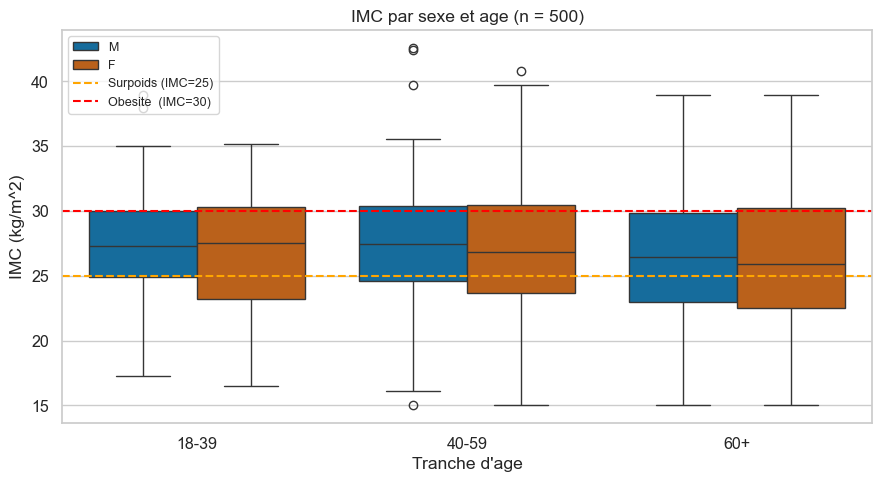

In [15]:
# Solution
n = 500
# np.random.choice tire au hasard dans une liste, avec proba optionnelle
clin = pd.DataFrame({
    "sexe":     np.random.choice(["M", "F"], n),
    "age_grp":  np.random.choice(["18-39", "40-59", "60+"], n,
                                  p=[0.3, 0.4, 0.3]),    # probas
    "imc":      np.random.normal(27, 5, n).clip(15, 50),
})

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=clin, x="age_grp", y="imc", hue="sexe",
    order=["18-39", "40-59", "60+"],   # ordre force des catégories
    palette=CB[:2], ax=ax,
)
ax.axhline(25, color="orange", ls="--", label="Surpoids (IMC=25)")
ax.axhline(30, color="red",    ls="--", label="Obesite  (IMC=30)")
ax.set_xlabel("Tranche d'age")
ax.set_ylabel("IMC (kg/m^2)")
ax.set_title(f"IMC par sexe et age (n = {n})")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

### Exercice 3 — Tableau de bord clinique 4 panneaux
Distributions, comparaisons, tendances pour 500 patients simules.

In [16]:
# Votre essai ici


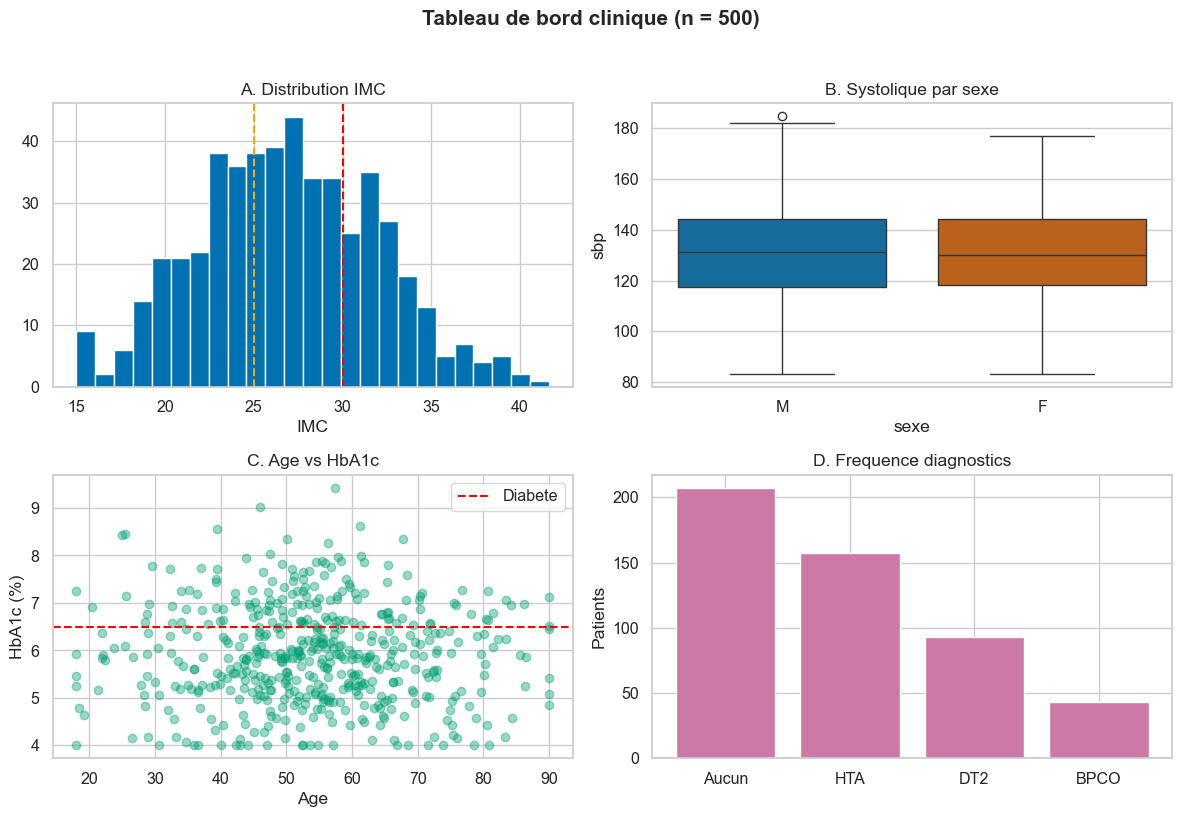

In [17]:
# Solution
n = 500
sim = pd.DataFrame({
    "sexe":   np.random.choice(["M", "F"], n),
    "age":    np.random.normal(55, 15, n).clip(18, 90),
    "imc":    np.random.normal(27, 5, n).clip(15, 50),
    "sbp":    np.random.normal(132, 18, n),
    "hba1c":  np.random.normal(5.9, 1.0, n).clip(4.0, 12.0),
    "dx":     np.random.choice(["HTA", "DT2", "BPCO", "Aucun"],
                                n, p=[0.30, 0.18, 0.07, 0.45]),
})

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# A. IMC + seuils
ax[0,0].hist(sim["imc"], bins=25, color=CB[0], edgecolor="white")
ax[0,0].axvline(25, color="orange", ls="--")
ax[0,0].axvline(30, color="red",    ls="--")
ax[0,0].set_xlabel("IMC"); ax[0,0].set_title("A. Distribution IMC")

# B. SBP par sexe
sns.boxplot(data=sim, x="sexe", y="sbp", ax=ax[0,1],
            hue="sexe", legend=False, palette=CB[:2])
ax[0,1].set_title("B. Systolique par sexe")

# C. Age vs HbA1c
ax[1,0].scatter(sim["age"], sim["hba1c"], alpha=0.4, color=CB[2])
ax[1,0].axhline(6.5, color="red", ls="--", label="Diabete")
ax[1,0].set_xlabel("Age"); ax[1,0].set_ylabel("HbA1c (%)")
ax[1,0].set_title("C. Age vs HbA1c"); ax[1,0].legend()

# D. Frequence diagnostics
freq = sim["dx"].value_counts()
ax[1,1].bar(freq.index, freq.values, color=CB[3])
ax[1,1].set_ylabel("Patients"); ax[1,1].set_title("D. Frequence diagnostics")

fig.suptitle(f"Tableau de bord clinique (n = {n})", y=1.02, fontweight="bold")
plt.tight_layout(); plt.show()

## Resume

Vous savez maintenant :

- choisir un type de graphique adapté a votre question ;
- annoter correctement pour une audience clinique ;
- composer un tableau de bord multi-panneaux et le sauvegarder.

**Suite -> Module 4** : tests d'hypothèses. Memes données, inference formelle.

## Ressources et liens utiles

### Documentation officielle

- **matplotlib** — https://matplotlib.org/stable/users/index.html
- **matplotlib gallery** (exemples avec code) — https://matplotlib.org/stable/gallery/index.html
- **seaborn** — https://seaborn.pydata.org/
- **seaborn gallery** — https://seaborn.pydata.org/examples/index.html

### Pourquoi pas de 3D, pas de camembert

- **Edward Tufte** *The Visual Display of Quantitative Information* (1983, reedition 2001) — la bible de la visualisation. Concepts cles : data-ink ratio, chartjunk, small multiples.
- **Wong, B. (2011)** *Color blindness*. Nature Methods 8: 441. https://www.nature.com/articles/nmeth.1618 — origine de la palette 8-couleurs accessible utilisee ici.
- **Okabe, M. & Ito, K. (2008)** *Color Universal Design (CUD)*. https://jfly.uni-koeln.de/color/

### Tutoriels pratiques

- **From data to viz** (https://www.data-to-viz.com/) — arbre de décision : selon le type de variables, quel graphe utiliser ?
- **Python Graph Gallery** (https://python-graph-gallery.com/) — catalogue de graphes avec code Python copiable.

### Pour aller plus loin

- **plotly** (graphiques interactifs) — https://plotly.com/python/
- **altair** (grammaire graphique declarative) — https://altair-viz.github.io/
- **kepler.gl / pydeck** (visualisation geospatiale) — voir Module 9 du cours 30 h.

<hr style="margin: 40px 0 16px 0; border: none; border-top: 1px solid #e0e0e0;"><div style="display: flex; justify-content: space-between; align-items: center; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;"><div style="flex: 1; text-align: left;"><a href="module_02_nettoyage_descriptif.ipynb" style="text-decoration: none; color: #0072B2; font-weight: 500;">&larr; Module 2 : Nettoyage et descriptif</a></div><div style="flex: 0; text-align: center; padding: 0 12px;"><a href="index.ipynb" style="text-decoration: none; color: #666666; font-size: 12px;">Sommaire du cours</a></div><div style="flex: 1; text-align: right;"><a href="module_04_tests_hypotheses.ipynb" style="text-decoration: none; color: #0072B2; font-weight: 500;">Module 4 : Tests d'hypothèses &rarr;</a></div></div>